In [12]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import os


In [13]:
#cancer_types = ["BRCA", "LUAD", "COAD", "PRAD"]
cancer_types = ["BRCA", "LUAD", "COAD", "PRAD", "BLCA", "KIRC", "HNSC", "LUSC", "SKCM", "STAD", "THCA"]
base_path = '../TCGA_Processed'

In [14]:
fpkm_data = {}

for cancer_type in cancer_types:
    try:
        fpkm_file = os.path.join(base_path, cancer_type, f"{cancer_type}_fpkm_counts.csv")
        fpkm_data[cancer_type] = pd.read_csv(fpkm_file)
    except FileNotFoundError:
        print(f"Missing file for {cancer_type}")


In [15]:
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import LabelEncoder

In [16]:
fpkm_data


{'BRCA':                                              Unnamed: 0 phenotype   TSPAN6  \
 0     1100a85c-823d-417b-a764-9282ec8593a5.rna_seq.a...      BRCA   7.9861   
 1     4ab26a32-f816-4aee-9130-12a0b3604db0.rna_seq.a...      BRCA   8.2965   
 2     616b6b60-8c4a-4d85-9a24-f47df6ad497e.rna_seq.a...      BRCA   5.9878   
 3     7db191ab-6106-4e39-a45e-8a68aaba0922.rna_seq.a...      BRCA   6.7643   
 4     b47b2efb-02e1-4729-95ad-de05fb551bc7.rna_seq.a...      BRCA   7.1322   
 ...                                                 ...       ...      ...   
 1226  89c5f174-7db7-426d-9530-41e08a8ef603.rna_seq.a...      BRCA  20.8000   
 1227  d78126ec-68b1-4d77-bf7a-19a47678a5fb.rna_seq.a...      BRCA  15.4209   
 1228  f1060adb-bee8-41f6-8997-2926d8967f33.rna_seq.a...      BRCA   7.0927   
 1229  c50bf088-8ad3-495c-b7b5-1eca9bb546ba.rna_seq.a...      BRCA  13.1367   
 1230  1a2bc49d-edc6-4b84-88f0-73b6ed250d1b.rna_seq.a...      BRCA  21.5552   
 
         TNMD     DPM1   SCYL3  C1orf112  

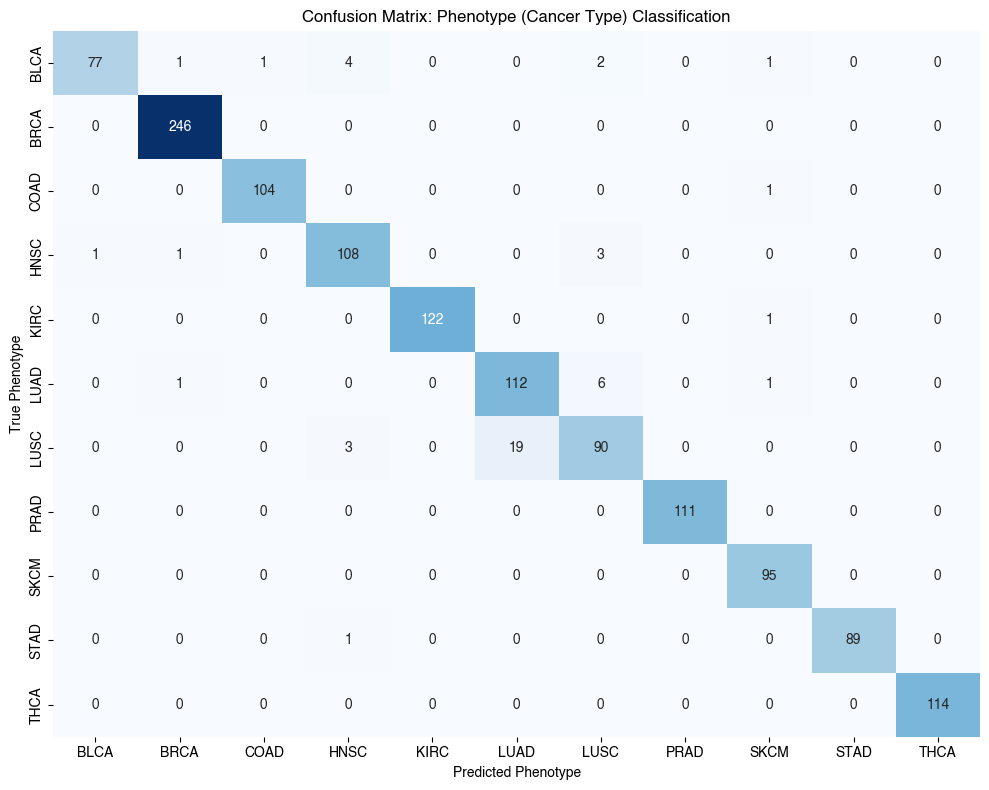


Classification Report:

              precision    recall  f1-score   support

        BLCA       0.99      0.90      0.94        86
        BRCA       0.99      1.00      0.99       246
        COAD       0.99      0.99      0.99       105
        HNSC       0.93      0.96      0.94       113
        KIRC       1.00      0.99      1.00       123
        LUAD       0.85      0.93      0.89       120
        LUSC       0.89      0.80      0.85       112
        PRAD       1.00      1.00      1.00       111
        SKCM       0.96      1.00      0.98        95
        STAD       1.00      0.99      0.99        90
        THCA       1.00      1.00      1.00       114

    accuracy                           0.96      1315
   macro avg       0.96      0.96      0.96      1315
weighted avg       0.96      0.96      0.96      1315



In [17]:
# --- Combine all data ---
all_data = []

for cancer_type, df in fpkm_data.items():
    temp = df.copy()
    temp = temp.set_index("Unnamed: 0")  # Set sample ID as index BEFORE appending
    all_data.append(temp)

# Combine all cancer types
combined_df = pd.concat(all_data, axis=0)

# --- Separate features and labels ---
y = combined_df["phenotype"]
X = combined_df.drop(columns=["phenotype"])

# --- Clean up: drop non-numeric columns (if any slipped in) ---
X = X.select_dtypes(include=[np.number])

# Drop any remaining NaNs
X = X.dropna(axis=1)
y = y.loc[X.index]  # align y with X


# Encode cancer types
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train Random Forest
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot Confusion Matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix: Phenotype (Cancer Type) Classification")
plt.xlabel("Predicted Phenotype")
plt.ylabel("True Phenotype")
plt.tight_layout()
plt.show()

# Classification Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


In [ ]:
preselected_path = "/Users/ndivhuwonyase/Desktop/IBM/TCGA_stage/preselected_genes.csv"

preselected_genes = pd.read_csv(preselected_path)


cancer_genes = list(set(list(preselected_genes["Cancer_Signalling_Genes"])))
housekeeping_genes = list(set(list(preselected_genes["House_Keeping_Genes"])))

Using 325 cancer signalling genes in classification.


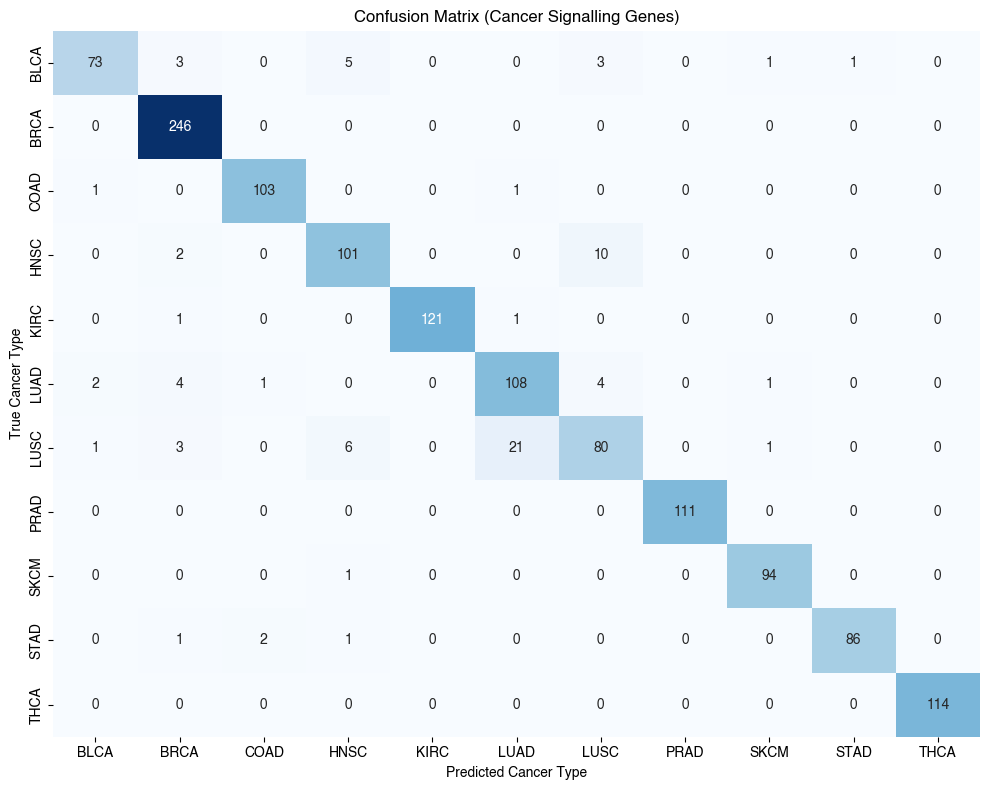


Classification Report (Cancer Signalling Genes):

              precision    recall  f1-score   support

        BLCA       0.95      0.85      0.90        86
        BRCA       0.95      1.00      0.97       246
        COAD       0.97      0.98      0.98       105
        HNSC       0.89      0.89      0.89       113
        KIRC       1.00      0.98      0.99       123
        LUAD       0.82      0.90      0.86       120
        LUSC       0.82      0.71      0.77       112
        PRAD       1.00      1.00      1.00       111
        SKCM       0.97      0.99      0.98        95
        STAD       0.99      0.96      0.97        90
        THCA       1.00      1.00      1.00       114

    accuracy                           0.94      1315
   macro avg       0.94      0.93      0.94      1315
weighted avg       0.94      0.94      0.94      1315



In [35]:
cancer_genes_in_data = [gene for gene in cancer_genes if gene in X.columns]
# Subset the expression matrix
X_cancer = X[cancer_genes_in_data]

print(f"Using {len(cancer_genes_in_data)} cancer signalling genes in classification.")
# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train model
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Cancer Signalling Genes)")
plt.xlabel("Predicted Cancer Type")
plt.ylabel("True Cancer Type")
plt.tight_layout()
plt.show()

# Classification report
print("\nClassification Report (Cancer Signalling Genes):\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


In [18]:
# Select top 200 most variable genes
X_top200 = X.loc[:, X.var().sort_values(ascending=False).head(200).index]
print(f"Selected top {X_top200.shape[1]} most variable genes.")


Selected top 200 most variable genes.


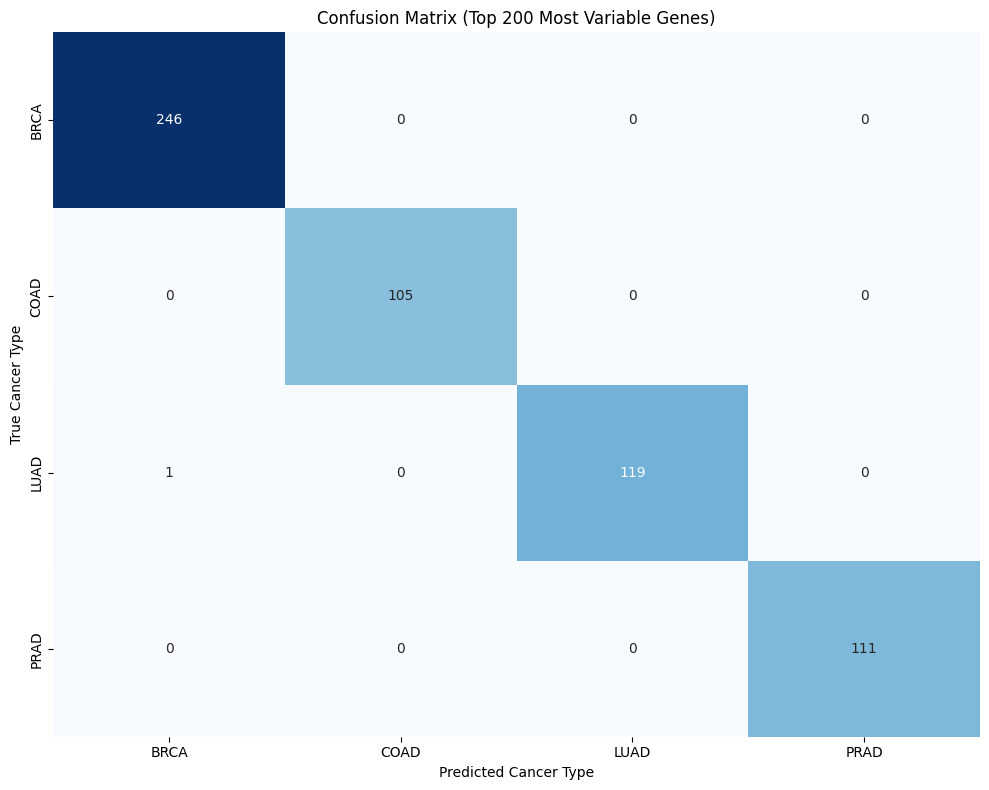


Classification Report:

              precision    recall  f1-score   support

        BRCA       1.00      1.00      1.00       246
        COAD       1.00      1.00      1.00       105
        LUAD       1.00      0.99      1.00       120
        PRAD       1.00      1.00      1.00       111

    accuracy                           1.00       582
   macro avg       1.00      1.00      1.00       582
weighted avg       1.00      1.00      1.00       582



In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Encode phenotype labels (cancer types)
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X_top200, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Train model
clf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight="balanced")
clf.fit(X_train, y_train)

# Predict
y_pred = clf.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
cm_df = pd.DataFrame(cm, index=label_encoder.classes_, columns=label_encoder.classes_)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.title("Confusion Matrix (Top 200 Most Variable Genes)")
plt.xlabel("Predicted Cancer Type")
plt.ylabel("True Cancer Type")
plt.tight_layout()
plt.show()

# Report
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


In [51]:
# Step 1: Reduce to top N most variable cancer genes
N = 200  # or 100, 200 depending on speed/memory

# Subset X to only cancer genes in the dataset
cancer_genes_in_data = [gene for gene in cancer_genes if gene in X.columns]
X_cancer = X[cancer_genes_in_data]

# Keep top N by variance
top_var_genes = X_cancer.var().sort_values(ascending=False).head(N).index.tolist()
X_cancer = X_cancer[top_var_genes]

# Step 2: Redefine X_train and X_test from reduced X_cancer
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y, test_size=0.2, random_state=42, stratify=y
)

# Step 3: Group by phenotype (cancer types)
cancer_types = pd.Series(y_train).unique()

stage_train_data = {}
stage_test_data = {}

for ct in cancer_types:
    train_mask = y_train == ct
    test_mask = y_test == ct
    stage_train_data[ct] = X_train[train_mask]
    stage_test_data[ct] = X_test[test_mask]



▶ Computing using: PEARSON
Computing the Simplicial Complex and persistence for patients


100%|██████████| 985/985 [02:07<00:00,  7.70it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 246/246 [00:30<00:00,  8.09it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


...

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 443/443 [02:04<00:00,  3.57it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 111/111 [00:32<00:00,  3.41it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value


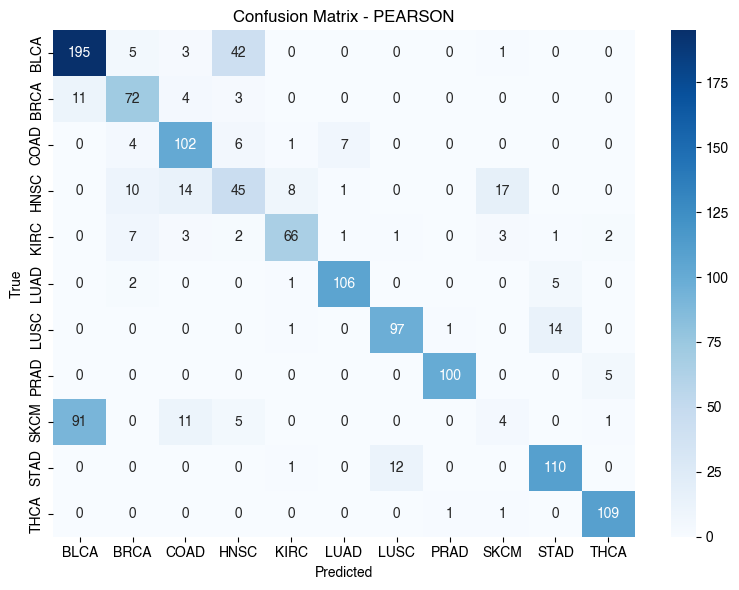


📊 Classification Report (pearson):

              precision    recall  f1-score   support

        BLCA       0.66      0.79      0.72       246
        BRCA       0.72      0.80      0.76        90
        COAD       0.74      0.85      0.79       120
        HNSC       0.44      0.47      0.45        95
        KIRC       0.85      0.77      0.80        86
        LUAD       0.92      0.93      0.93       114
        LUSC       0.88      0.86      0.87       113
        PRAD       0.98      0.95      0.97       105
        SKCM       0.15      0.04      0.06       112
        STAD       0.85      0.89      0.87       123
        THCA       0.93      0.98      0.96       111

    accuracy                           0.77      1315
   macro avg       0.74      0.76      0.74      1315
weighted avg       0.73      0.77      0.74      1315


▶ Computing using: DISTCORR
Computing the Simplicial Complex and persistence for patients


100%|██████████| 985/985 [00:41<00:00, 23.70it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 246/246 [00:10<00:00, 23.64it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


...

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 443/443 [00:30<00:00, 14.37it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 111/111 [00:07<00:00, 14.64it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value


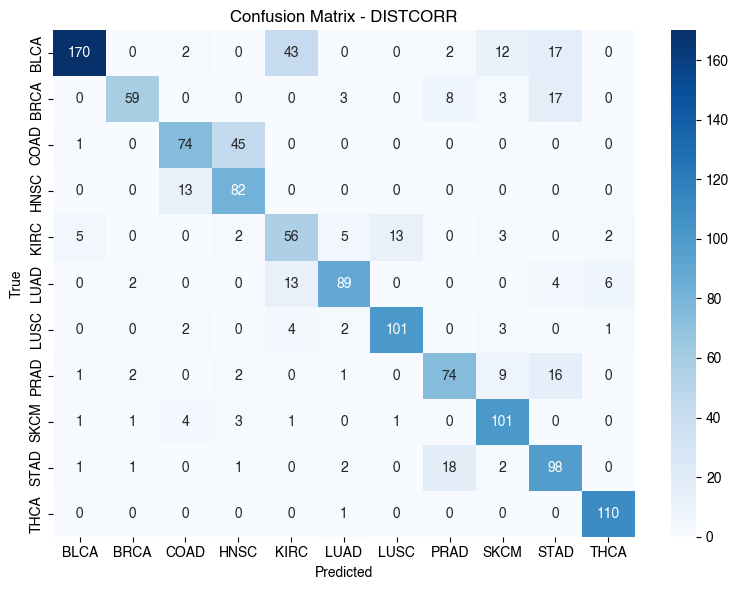


📊 Classification Report (distcorr):

              precision    recall  f1-score   support

        BLCA       0.95      0.69      0.80       246
        BRCA       0.91      0.66      0.76        90
        COAD       0.78      0.62      0.69       120
        HNSC       0.61      0.86      0.71        95
        KIRC       0.48      0.65      0.55        86
        LUAD       0.86      0.78      0.82       114
        LUSC       0.88      0.89      0.89       113
        PRAD       0.73      0.70      0.71       105
        SKCM       0.76      0.90      0.82       112
        STAD       0.64      0.80      0.71       123
        THCA       0.92      0.99      0.96       111

    accuracy                           0.77      1315
   macro avg       0.77      0.78      0.77      1315
weighted avg       0.80      0.77      0.77      1315


▶ Computing using: WTO_PEARSON
Computing the Simplicial Complex and persistence for patients


100%|██████████| 985/985 [00:36<00:00, 27.29it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 246/246 [00:09<00:00, 26.93it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


...

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 443/443 [00:17<00:00, 25.39it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 111/111 [00:04<00:00, 25.77it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value


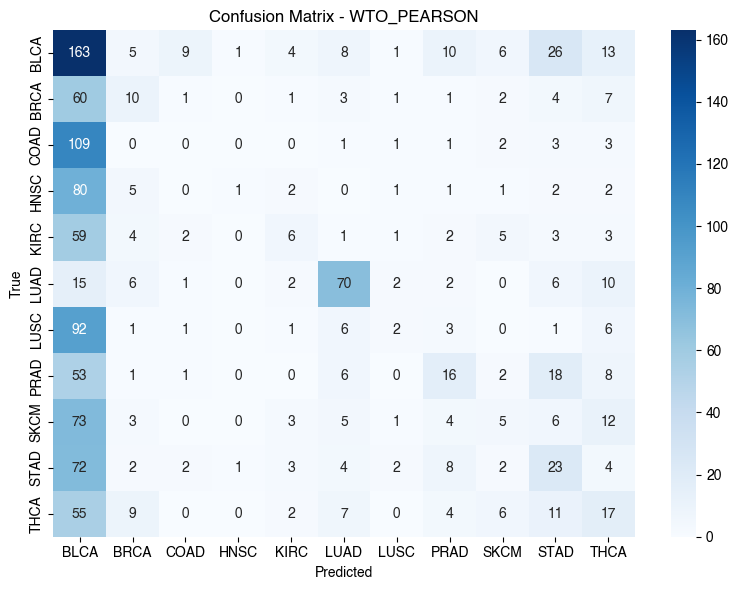


📊 Classification Report (wto_pearson):

              precision    recall  f1-score   support

        BLCA       0.20      0.66      0.30       246
        BRCA       0.22      0.11      0.15        90
        COAD       0.00      0.00      0.00       120
        HNSC       0.33      0.01      0.02        95
        KIRC       0.25      0.07      0.11        86
        LUAD       0.63      0.61      0.62       114
        LUSC       0.17      0.02      0.03       113
        PRAD       0.31      0.15      0.20       105
        SKCM       0.16      0.04      0.07       112
        STAD       0.22      0.19      0.20       123
        THCA       0.20      0.15      0.17       111

    accuracy                           0.24      1315
   macro avg       0.24      0.18      0.17      1315
weighted avg       0.24      0.24      0.19      1315


▶ Computing using: WTO_DISTCORR
Computing the Simplicial Complex and persistence for patients


100%|██████████| 985/985 [00:38<00:00, 25.86it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 246/246 [00:09<00:00, 25.81it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


...

Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 443/443 [00:17<00:00, 25.60it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value
Computing the Simplicial Complex and persistence for patients


100%|██████████| 111/111 [00:04<00:00, 25.60it/s]
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/gudhi/representations/vector_methods.py:208: RuntimeWarning: invalid value encountered in subtract
  tent_functions = np.maximum(heights[None, :] - np.abs(x_values[:, None] - midpoints[None, :]), 0)


Empty list or empty diagrams: sample range is [-inf, -inf]
First value and second value in range are the same: grid is made of resolution copies of this value


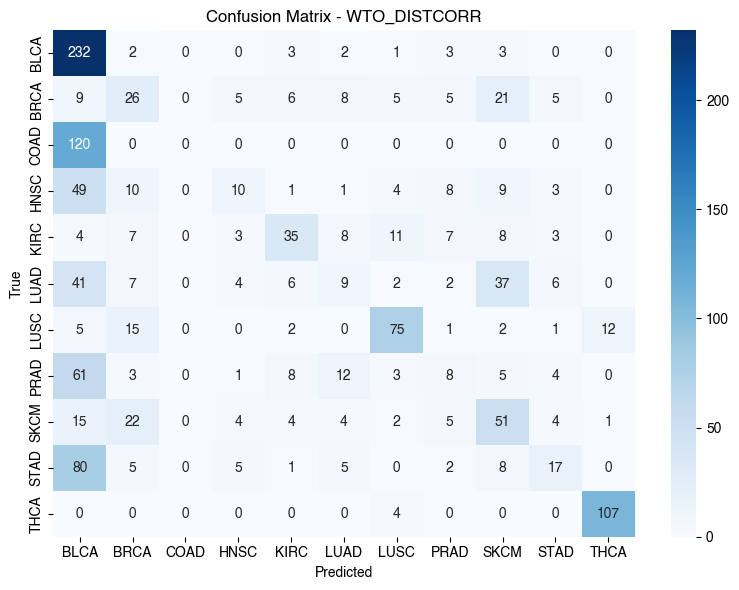


📊 Classification Report (wto_distcorr):

              precision    recall  f1-score   support

        BLCA       0.38      0.94      0.54       246
        BRCA       0.27      0.29      0.28        90
        COAD       0.00      0.00      0.00       120
        HNSC       0.31      0.11      0.16        95
        KIRC       0.53      0.41      0.46        86
        LUAD       0.18      0.08      0.11       114
        LUSC       0.70      0.66      0.68       113
        PRAD       0.20      0.08      0.11       105
        SKCM       0.35      0.46      0.40       112
        STAD       0.40      0.14      0.20       123
        THCA       0.89      0.96      0.93       111

    accuracy                           0.43      1315
   macro avg       0.38      0.37      0.35      1315
weighted avg       0.38      0.43      0.37      1315



/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/ndivhuwonyase/miniforge3/envs/wgtda2/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(ave

In [53]:
from src.functions import compute_wto_matrix, compute_distance_correlation_matrix, compute_pearson_correlation_matrix, compute_simplicial_complex_and_landscapes
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

methods = {
    "pearson": compute_pearson_correlation_matrix,
    "distcorr": compute_distance_correlation_matrix,
    "wto_pearson": lambda X: compute_wto_matrix(X, "pearsons"),
    "wto_distcorr": lambda X: compute_wto_matrix(X, "dc")
}

num_landscape = 3
resolution = 50

results = {}

for name, matrix_func in methods.items():
    print(f"\n▶ Computing using: {name.upper()}")

    train_landscapes = []
    train_labels = []
    test_landscapes = []
    test_labels = []

    for idx, ct in enumerate(cancer_types):
        train_expr = stage_train_data[ct]
        test_expr = stage_test_data[ct]

        # Compute the co-expression network matrix (Pearson, WTO, etc.)
        matrix = matrix_func(train_expr.values)

        # Compute landscapes
        train_ls = compute_simplicial_complex_and_landscapes(train_expr.values, matrix, num_landscape, resolution)
        test_ls = compute_simplicial_complex_and_landscapes(test_expr.values, matrix, num_landscape, resolution)

        # Store
        train_landscapes.append(train_ls)
        test_landscapes.append(test_ls)
        train_labels.append(np.full(train_ls.shape[0], idx))
        test_labels.append(np.full(test_ls.shape[0], idx))

    # Combine all classes
    X_train = np.vstack(train_landscapes)
    y_train = np.concatenate(train_labels)
    X_test = np.vstack(test_landscapes)
    y_test = np.concatenate(test_labels)

    # Train Random Forest
    clf = RandomForestClassifier(n_estimators=200, random_state=42)
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)

    # Store results
    results[name] = {
        "model": clf,
        "y_true": y_test,
        "y_pred": y_pred
    }

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", 
                xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
    plt.title(f"Confusion Matrix - {name.upper()}")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.show()

    # Classification Report
    print(f"\n📊 Classification Report ({name}):\n")
    print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))



In [37]:
# Stack all cancer types' landscapes and labels
X_train_landscapes = np.vstack(train_landscapes)
X_test_landscapes = np.vstack(test_landscapes)
y_train_labels = np.concatenate(train_labels)
y_test_labels = np.concatenate(test_labels)

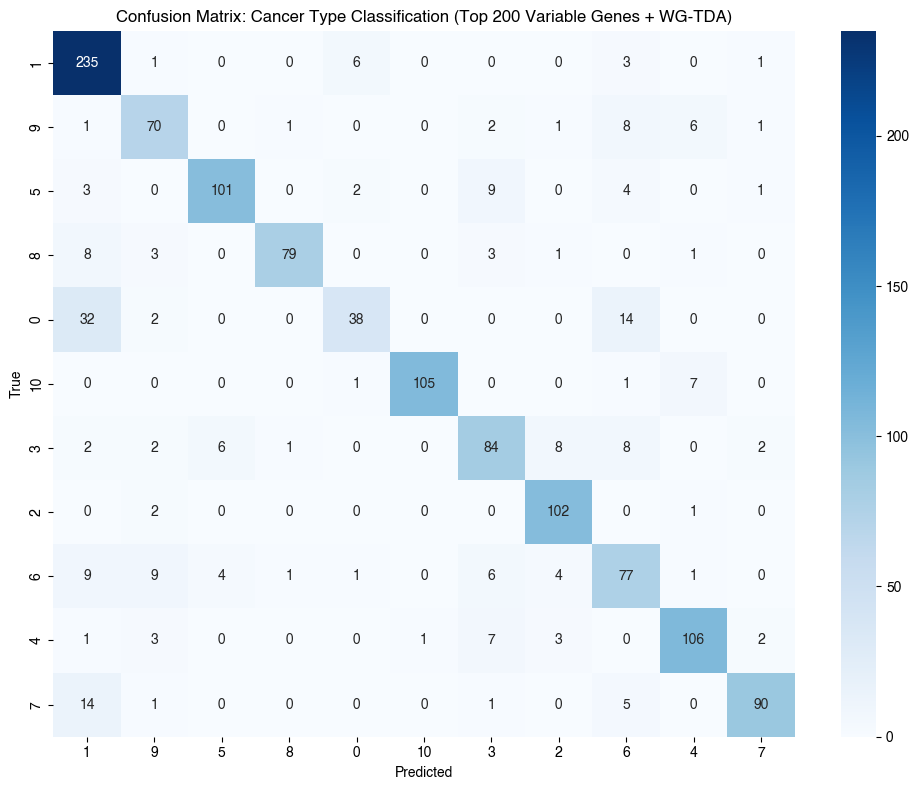

              precision    recall  f1-score   support

           1       0.77      0.96      0.85       246
           9       0.75      0.78      0.77        90
           5       0.91      0.84      0.87       120
           8       0.96      0.83      0.89        95
           0       0.79      0.44      0.57        86
          10       0.99      0.92      0.95       114
           3       0.75      0.74      0.75       113
           2       0.86      0.97      0.91       105
           6       0.64      0.69      0.66       112
           4       0.87      0.86      0.87       123
           7       0.93      0.81      0.87       111

    accuracy                           0.83      1315
   macro avg       0.84      0.80      0.81      1315
weighted avg       0.83      0.83      0.82      1315



In [38]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

clf = RandomForestClassifier(n_estimators=200, random_state=42)
clf.fit(X_train_landscapes, y_train_labels)
y_pred = clf.predict(X_test_landscapes)

# Confusion Matrix
cm = confusion_matrix(y_test_labels, y_pred)
cm_df = pd.DataFrame(cm, index=cancer_types, columns=cancer_types)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix: Cancer Type Classification (Top 200 Variable Genes + WG-TDA)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

target_names = [str(name) for name in cancer_types]
print(classification_report(y_test_labels, y_pred, target_names=target_names))
